In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df=pd.read_csv("E:\\ML_Project\\ml_project_1\\notebook\\data\\student.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape
df.info()
print("######Description of the dataset##########")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
######Description of the dataset##########


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Check missing value

In [4]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### check duplicate values

In [5]:

df.duplicated().sum()

np.int64(0)

## seperate column type

In [6]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns

In [9]:
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['math score', 'reading score', 'writing score'], dtype='object')
Categorical columns: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


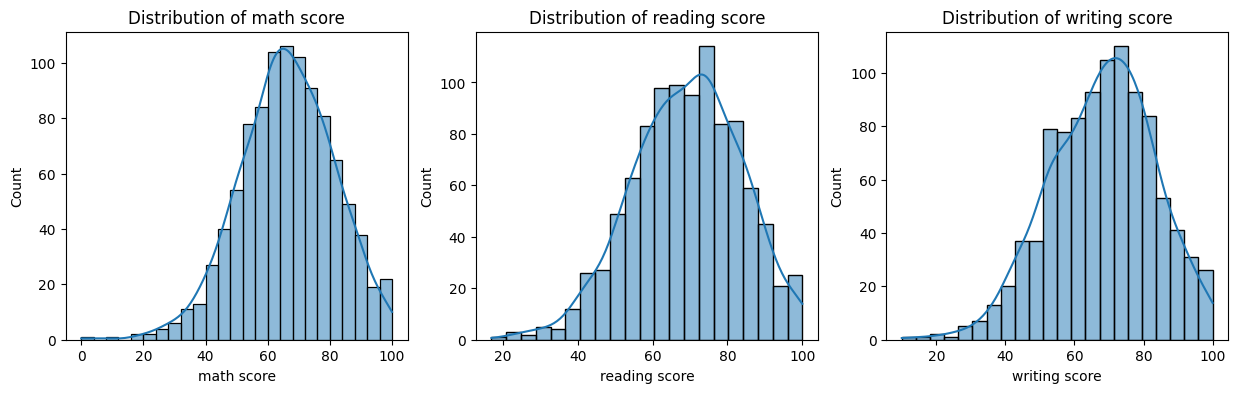

In [21]:
n_cols=len(num_cols)
fig,axs=plt.subplots(1,n_cols,figsize=(5*n_cols,4))
for i,col in enumerate(num_cols):
    sns.histplot(x=col,data=df,ax=axs[i],kde=True)
    axs[i].set_title(f'Distribution of {col}')

## Exist right skewness  
## Exist outliners

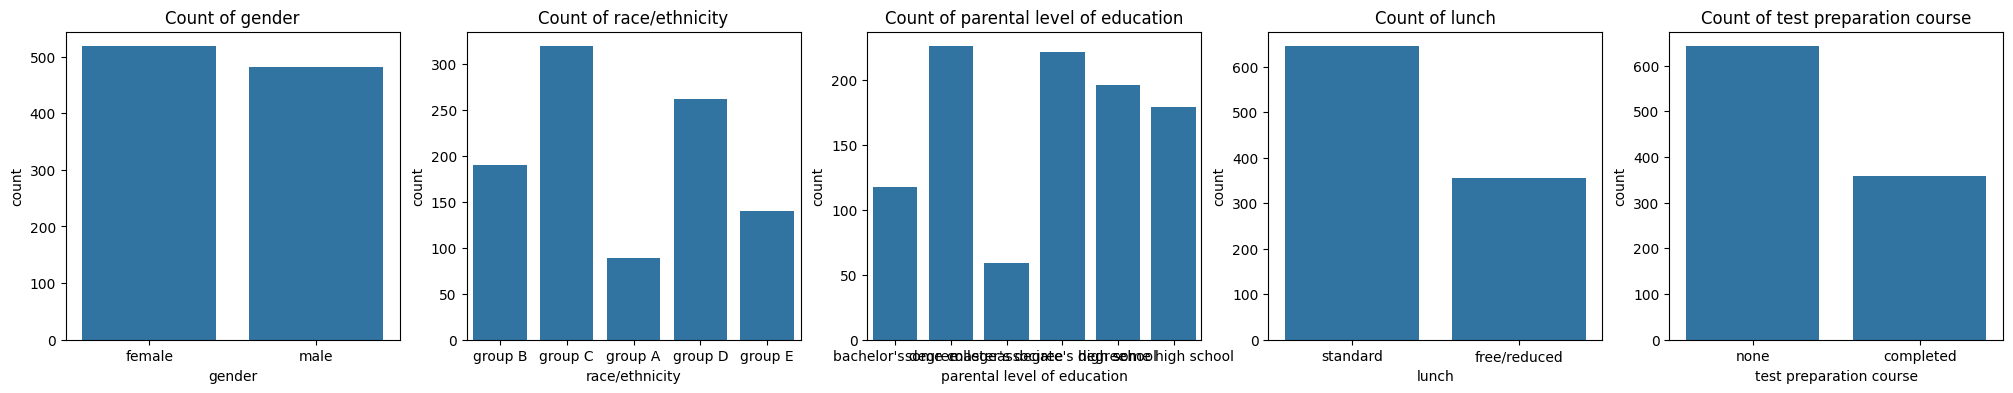

In [20]:
n_cols=len(cat_cols)
fig,axs=plt.subplots(1,n_cols,figsize=(5*n_cols,4))
for i,col in enumerate(cat_cols):
    sns.countplot(x=col,data=df,ax=axs[i])
    axs[i].set_title(f'Count of {col}')

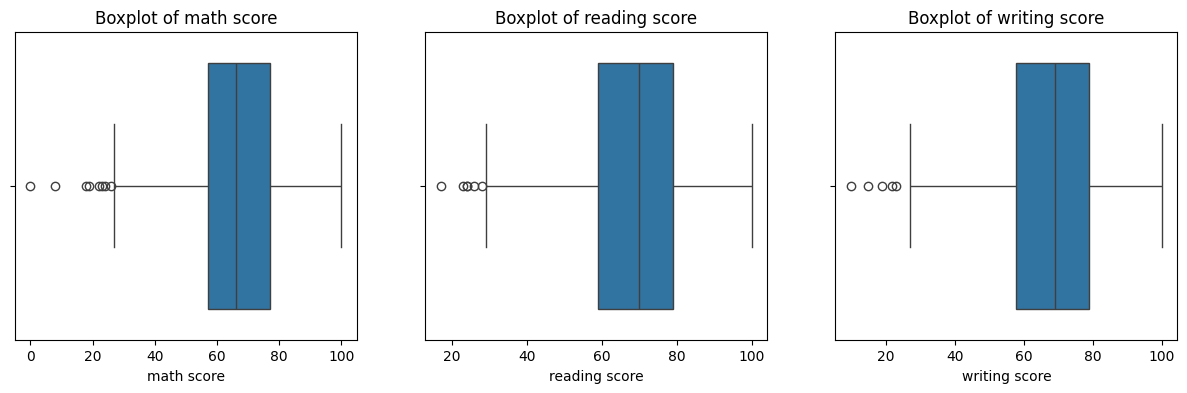

In [26]:

n_cols=len(num_cols)
fig,axs=plt.subplots(1,n_cols,figsize=(5*n_cols,4))
for i,col in enumerate(num_cols):
    sns.boxplot(x=col,data=df,ax=axs[i])
    axs[i].set_title(f'Boxplot of {col}')

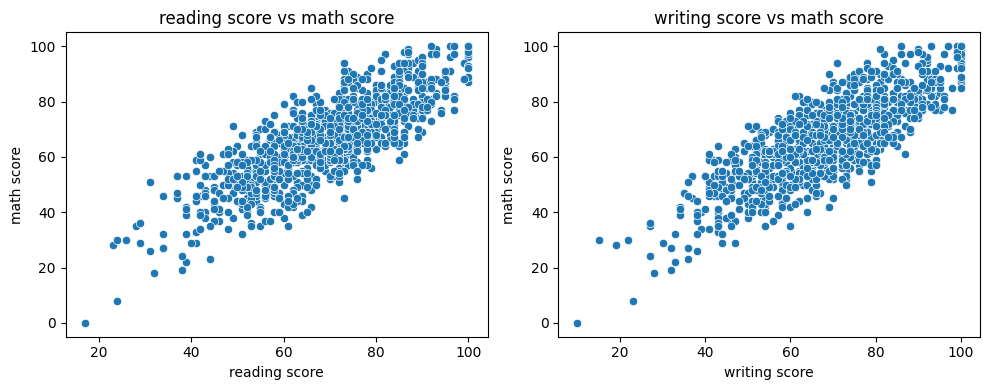

In [29]:
target_col='math score'
other_num_cols=[col for col in num_cols if col!=target_col]
n_cols=len(other_num_cols)
fig,axs=plt.subplots(1,n_cols,figsize=(5*n_cols,4))
for i,col in enumerate(other_num_cols):
    sns.scatterplot(x=col,y=target_col,data=df,ax=axs[i])
    axs[i].set_title(f'{col} vs {target_col}')

plt.tight_layout()
plt.show()

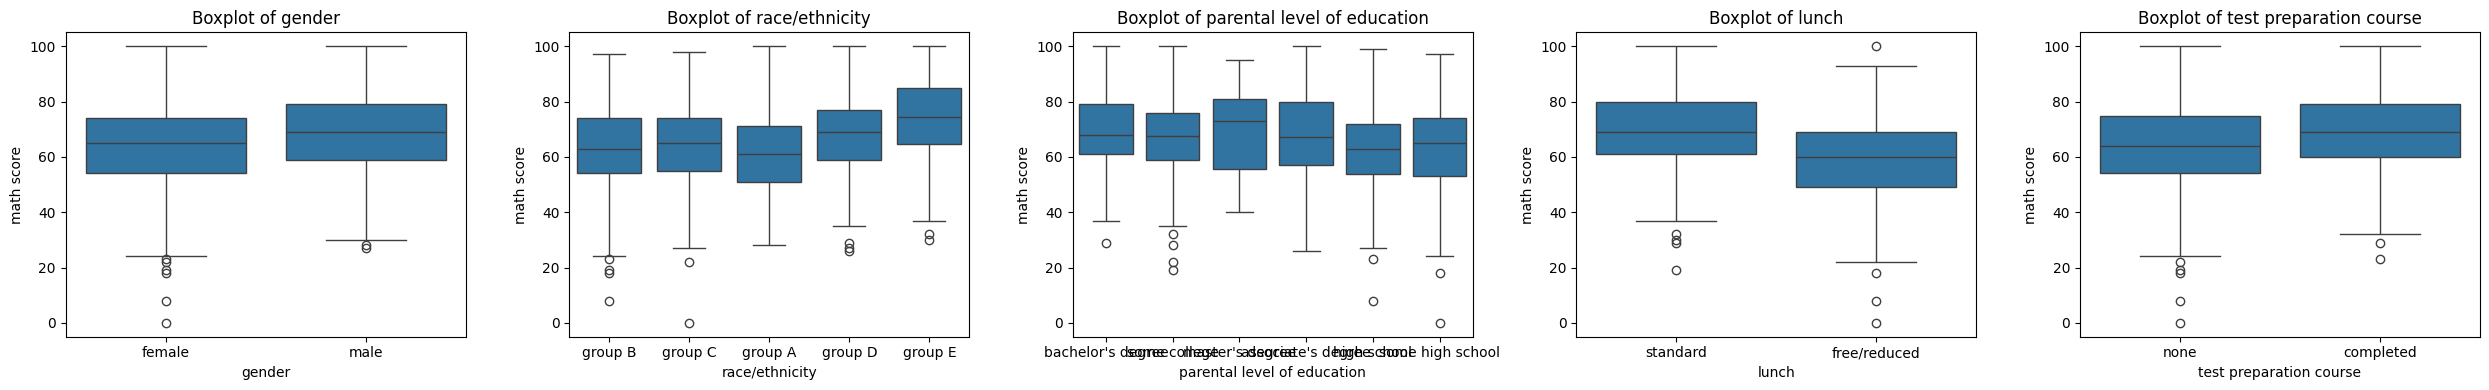

In [38]:
target_col='math score'
other_cat_cols=[col for col in cat_cols if col!=target_col]
n_cols=len(other_cat_cols)
fig,axs=plt.subplots(1,n_cols,figsize=(5*n_cols,4))
for i,col in enumerate(other_cat_cols):
    sns.boxplot(x=col,y=target_col,data=df,ax=axs[i])
    axs[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [39]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [41]:
df['average_score']=df.apply(lambda row:(row['math score']+row['reading score']+row['writing score'])/3,axis=1)

In [42]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [43]:
df.drop(['math score', 'reading score', 'writing score'], axis=1, inplace=True)

In [44]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,average_score
0,female,group B,bachelor's degree,standard,none,72.666667
1,female,group C,some college,standard,completed,82.333333
2,female,group B,master's degree,standard,none,92.666667
3,male,group A,associate's degree,free/reduced,none,49.333333
4,male,group C,some college,standard,none,76.333333


Text(0.5, 1.0, 'Distribution of Average Score')

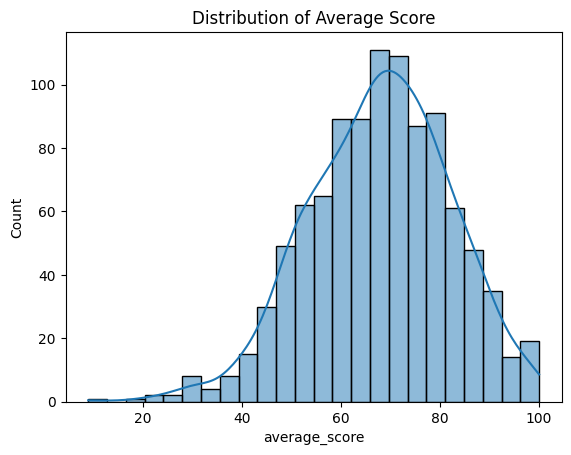

In [45]:
sns.histplot(x='average_score',data=df,kde=True)
plt.title('Distribution of Average Score')

Text(0.5, 1.0, 'Boxplot of Average Score')

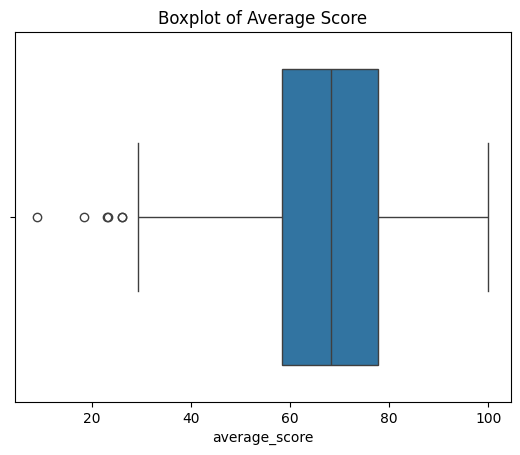

In [46]:
sns.boxplot(x='average_score',data=df)
plt.title('Boxplot of Average Score')

## Encoding 

In [48]:
df.corr()

ValueError: could not convert string to float: 'female'

In [47]:
heatmap_data=df.corr()
sns.heatmap(heatmap_data,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'female'